In [ ]:
# Credit Risk Analysis - Python Validation

"""
Objetivo:
Validar y cuantificar la lógica de riesgo reconstruida a partir del análisis previo en Power BI y SQL.

En este notebook:
- Se replica la segmentación basada en data (NTILE)
- Se reconstruye el modelo de riesgo
- Se compara contra el modelo original
- Se evalúa capacidad predictiva básica
"""

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("loan_data.csv")
df.head()

Saving loan_data.csv to loan_data (1).csv


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [ ]:
df["dti"] = df["loan_percent_income"]

In [ ]:
df[["loan_status", "person_income", "dti"]].corr()

,loan_status,person_income,dti
loan_status,1.000000,-0.135808,0.384880
person_income,-0.135808,1.000000,-0.234177
dti,0.384880,-0.234177,1.000000


In [ ]:
df["dti_group"] = pd.qcut(df["dti"], 5)

In [ ]:
df.groupby("dti_group")["loan_status"].mean()

/tmp/ipykernel_12491/3999365312.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("dti_group")["loan_status"].mean()


,loan_status
dti_group,
"(-0.001, 0.06]",0.109057
"(0.06, 0.1]",0.126183
"(0.1, 0.14]",0.157084
"(0.14, 0.21]",0.200165
"(0.21, 0.66]",0.553484


/tmp/ipykernel_12491/2963020308.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("dti_group")["loan_status"].mean().reset_index()


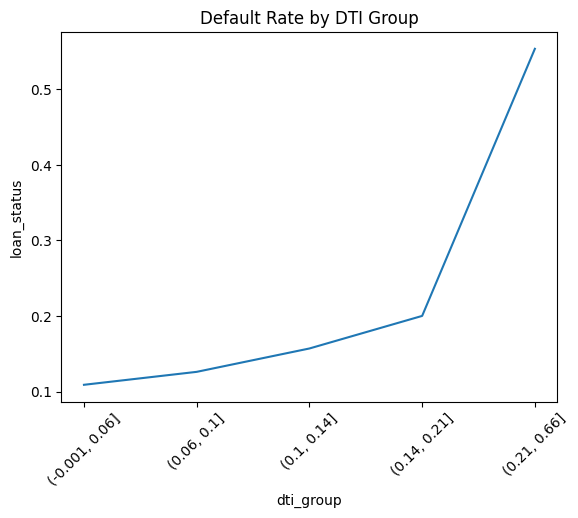

In [ ]:
grouped = df.groupby("dti_group")["loan_status"].mean().reset_index()

sns.lineplot(x=grouped["dti_group"].astype(str), y=grouped["loan_status"])

plt.xticks(rotation=45)
plt.title("Default Rate by DTI Group")
plt.show()

In [ ]:
# Segmentación income
df["income_group"] = pd.qcut(df["person_income"], 5)

# Convertimos a números (0–4)
df["income_score"] = pd.qcut(df["person_income"], 5, labels=False)
df["dti_score"] = pd.qcut(df["dti"], 5, labels=False)

# Risk score (más peso a DTI)
df["risk_score"] = df["dti_score"] * 0.7 + df["income_score"] * 0.3

# Agrupamos en niveles
df["risk_group"] = pd.qcut(df["risk_score"], 5)

In [ ]:
df.groupby("risk_group")["loan_status"].mean()

/tmp/ipykernel_12491/3925179555.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("risk_group")["loan_status"].mean()


,loan_status
risk_group,
"(-0.001, 1.2]",0.130030
"(1.2, 1.7]",0.159537
"(1.7, 2.3]",0.176449
"(2.3, 2.8]",0.319623
"(2.8, 4.0]",0.353971


/tmp/ipykernel_12491/3870493383.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("risk_group")["loan_status"].mean().reset_index()


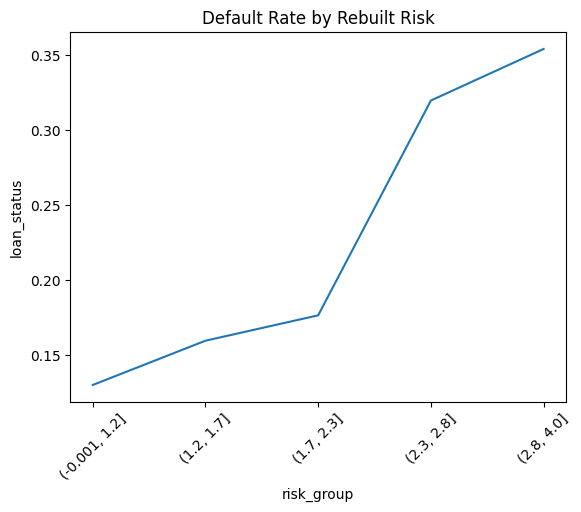

In [ ]:
grouped = df.groupby("risk_group")["loan_status"].mean().reset_index()

sns.lineplot(x=grouped["risk_group"].astype(str), y=grouped["loan_status"])

plt.xticks(rotation=45)
plt.title("Default Rate by Rebuilt Risk")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X = df[["dti", "person_income"]]
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

np.float64(0.7406642197146587)

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[["dti", "person_income"]]
y = df["loan_status"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

pd.DataFrame({
    "Variable": ["dti", "income"],
    "Coeficiente": model.coef_[0]
})

,Variable,Coeficiente
0,dti,0.800473
1,income,-0.777025
